Dataset Preview:
    CustomerID Gender   Age  Annual Income (k$)  Spending Score (1-100)
0        1000      M  39.0                59.9                    58.0
1        1001      M  34.0                48.4                    37.0
2        1002      F  40.0                70.5                    26.0
3        1003      F  47.0                81.1                    30.0
4        1004      F  33.0                42.1                    58.0

Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


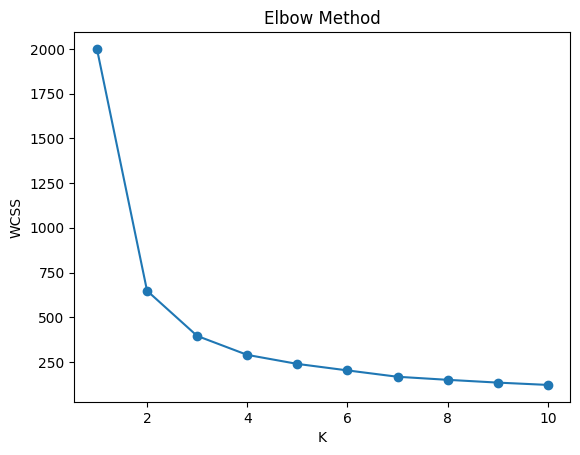

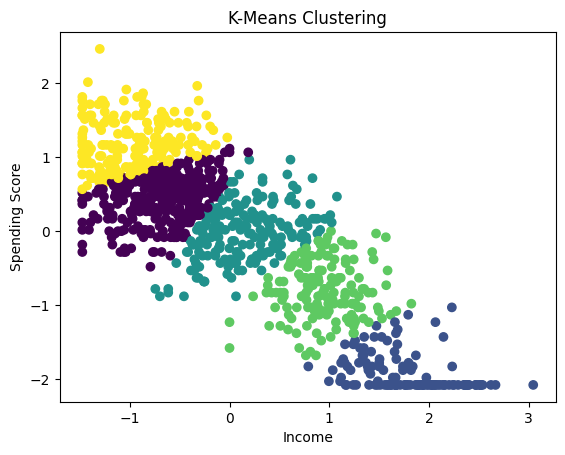

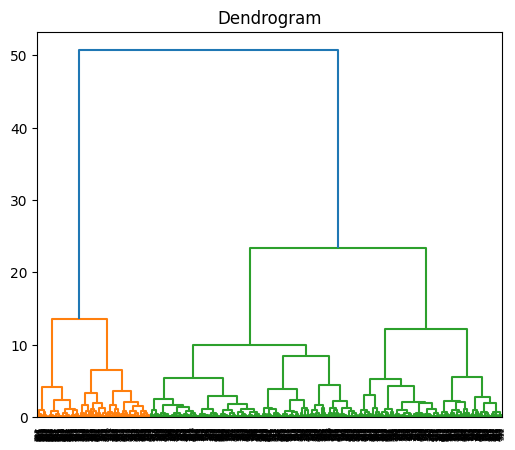

In [1]:
# ================= STEP 1: IMPORT =================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


# ================= STEP 2: LOAD DATA =================
df = pd.read_csv("store_customers.csv")


print("Dataset Preview:\n", df.head())
print("\nColumns:", df.columns)


# ================= STEP 3: HANDLE MISSING VALUES =================
df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].mean())
df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].mean())


# ================= STEP 4: SELECT FEATURES =================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]


# ================= STEP 5: SCALING =================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ================= STEP 6: ELBOW METHOD =================
wcss = []


for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()


# ================= STEP 7: K-MEANS =================
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)


plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()


# ================= STEP 8: HIERARCHICAL =================
linked = linkage(X_scaled, method='ward')


plt.figure(figsize=(6,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()
